# Learning resources:

* https://quantum.cloud.ibm.com/docs/en/guides
* https://quantum.cloud.ibm.com/docs/en/guides
* https://quantum.cloud.ibm.com/learning/
* https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/introduction
* https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/introduction
* https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/introduction

## I. Overview of **quantum composer**: implementing 1, 2 and 3 qubits quantum circuits, Hadamard gate (H), not gate (X), Controlled not gate (CX), measurement, probability amplitude
Access composer at https://quantum.cloud.ibm.com/composer

## Excercises:
### 1. Create quantum circuits generating following states using quantum composer :

a) a single qubit state wich is an equal superposition of basis states:<br>
* $|+\rangle=\frac{1}{\sqrt{2}}\left(|0\rangle +|1\rangle\right)$<br>

b) a single qubit state wich is an equal superposition of basis states of the following form:<br>
* $|-\rangle=\frac{1}{\sqrt{2}}\left(|0\rangle -|1\rangle\right)$<br>

c) the two qubit state wich is an equal superposition of basis states:<br>
* $HH|00\rangle= \frac{1}{2}\left(|00\rangle+|01\rangle+|10\rangle+|11\rangle\right)$<br>

d) one of the two qubit Bell states (https://en.wikipedia.org/wiki/Bell_state):<br>
* $|\Psi^+\rangle=\frac{1}{\sqrt{2}}\left(|01\rangle +|10\rangle\right)$,<br>
* $|\Psi^-\rangle=\frac{1}{\sqrt{2}}\left(|01\rangle -|10\rangle\right)$,<br>
* $|\Phi^+\rangle=\frac{1}{\sqrt{2}}\left(|00\rangle +|11\rangle\right)$,<br>
* $|\Phi^-\rangle=\frac{1}{\sqrt{2}}\left(|00\rangle -|11\rangle\right)$.<br>

e) a three qubit state wich is an equal superposition of basis states:<br>
* $HHH|000\rangle= \frac{1}{\sqrt{8}}\left(|000\rangle+|001\rangle+|010\rangle+|011\rangle+|100\rangle+|101\rangle+|110\rangle+|111\rangle\right)$<br>

f) a three qubit GHZ state (https://en.wikipedia.org/wiki/Greenberger%E2%80%93Horne%E2%80%93Zeilinger_state):<br>
* $|GHZ\rangle=\frac{1}{\sqrt{2}}\left(|000\rangle +|111\rangle\right)$

## II. Single Qubit States and Rotations in Qiskit, Jupyter Notebook

## Excercises:

### 1. Translate your understanding of the Bloch sphere and basic gates ($X$, $Y$, $Z$, $H$, $S$) into Qiskit code.

Try to reach the target states by applying the correct rotations. For each exercise, output the state using LaTeX representation and plot it on the Bloch sphere.  Using the ```visualize_transition``` function from the ```visualization``` module, show the tranistions from the  initial state $|0\rangle$. By default, states in Qiskit start in $|0\rangle$. Fill the code below:

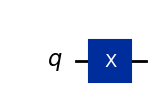

<IPython.core.display.Latex object>

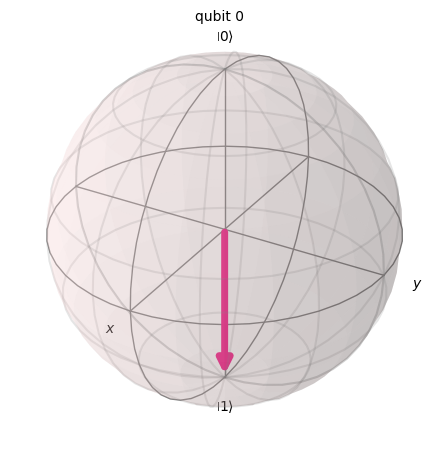

In [1]:
# Exercise 2.1: Bit Flip
# Reach the state |1> from the initial |0> state.
# Visualize resulting state on teh Bloch sphere

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

qc1 = QuantumCircuit(1)

qc1.x(0)

display(qc1.draw('mpl'))

state = Statevector.from_instruction(qc1)
display(state.draw(output='latex'))

display(state.draw('bloch'))


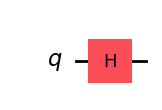

<IPython.core.display.Latex object>

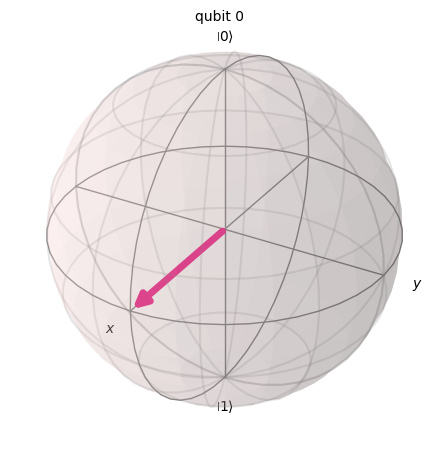

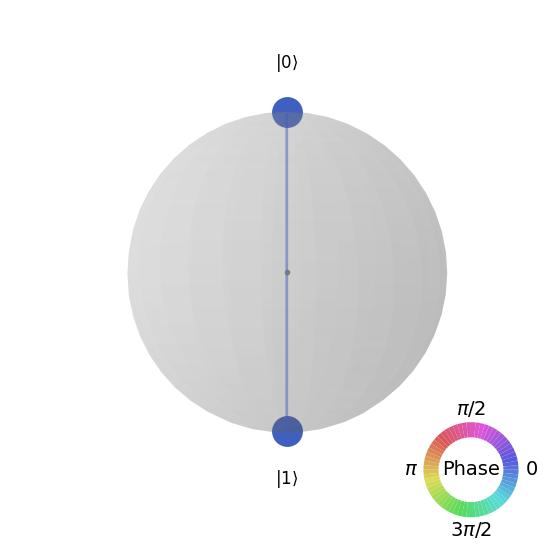

In [2]:
# Exercise 2.2: Standard Superposition
# Reach the state |+> = 1/sqrt(2) * (|0> + |1>)
# Visualize resulting state on teh Bloch sphere
# Visualize resulting state on teh QSphere and analyze the phase information.
qc2 = QuantumCircuit(1)

qc2.h(0)

display(qc2.draw('mpl'))

state = Statevector.from_instruction(qc2)

display(state.draw(output='latex'))

display(state.draw('bloch'))

display(state.draw('qsphere'))


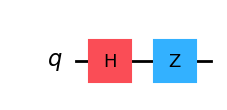

<IPython.core.display.Latex object>

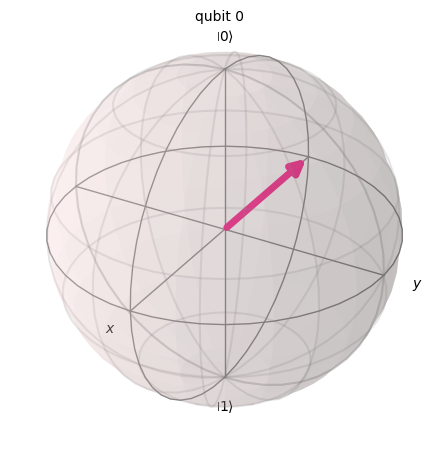

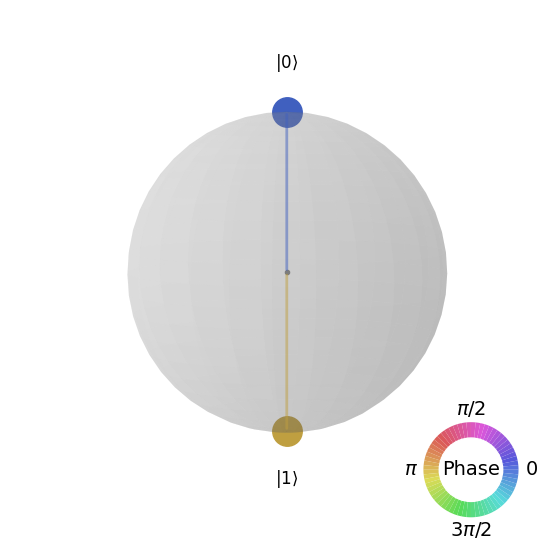

In [3]:
# Exercise 2.3: Phase Shifted Superposition
# Reach the state |-> = 1/sqrt(2) * (|0> - |1>)
# Challenge: Can you do this in more than one way?
# Visualize resulting state on teh Bloch sphere
# Visualize resulting state on teh QSphere and analyze the phase information.
qc3 = QuantumCircuit(1)
# qc3.x(0)
# qc3.h(0) #second way

qc3.h(0)
qc3.z(0)

display(qc3.draw('mpl'))

state = Statevector.from_instruction(qc3)

display(state.draw(output='latex'))

display(state.draw('bloch'))

display(state.draw('qsphere'))

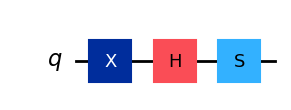

<IPython.core.display.Latex object>

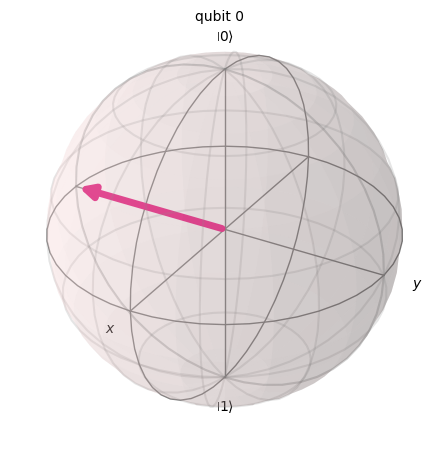

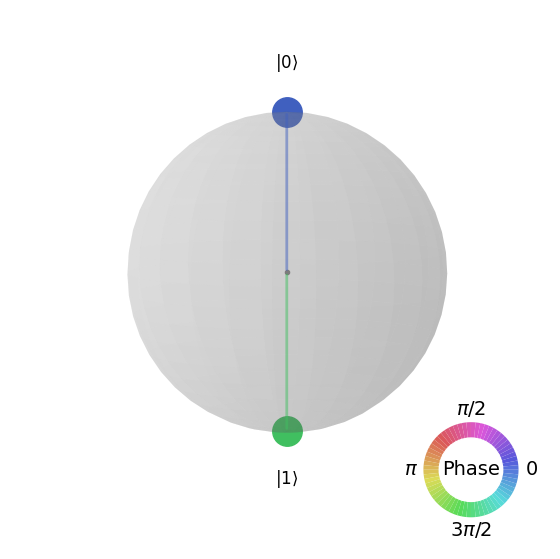

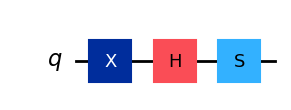

In [4]:
# Exercise 2.4: Complex Superposition
# Reach the state |-i> = 1/sqrt(2) * (|0> - i|1>)
qc4 = QuantumCircuit(1)
qc4.x(0)
qc4.h(0)
qc4.s(0)

display(qc4.draw('mpl'))

state = Statevector.from_instruction(qc4)

display(state.draw(output='latex'))

display(state.draw('bloch'))

display(state.draw('qsphere'))


display(qc4.draw('mpl'))

### 2. Initialization
Using Qiskit, e.g. ```initialize``` function, prepare a single qubit in a state where the probability of measuring $|0\rangle$ is $1/3$, and the probability of measuring $|1\rangle$ is $2/3$. Mathematically prove that the state of your prepared qubit fulfills these requirements.

In [5]:
from math import sqrt
qc_state = QuantumCircuit(1)

initial_state = [1/sqrt(3), sqrt(2/3)]
qc_state.initialize(initial_state, 0)

state = Statevector.from_instruction(qc_state)
print(state)
state.draw('latex')

Statevector([0.57735027+0.j, 0.81649658+0.j],
            dims=(2,))


<IPython.core.display.Latex object>

### 3. Measurements

Using Qiskit, determine the measurement probabilities for a qubit initialized in the computational basis state $|0\rangle$ when measured in different bases:
* The X-basis (states $|+\rangle$ and $|-\rangle$)
* The Y-basis (states $|+i\rangle$ and $|-i\rangle$)

In [6]:
from IPython.display import display

print("x-basis")
qc_x = QuantumCircuit(1)

initial_state = [1, 0]
qc_x.initialize(initial_state, 0)

qc_x.h(0)

state = Statevector.from_instruction(qc_x)

print(state)
display(state.draw("latex"))

print("Y-basis")
qc_y = QuantumCircuit(1)

qc_y.initialize(initial_state, 0)

qc_y.sdg(0)
qc_y.h(0)

state_y = Statevector.from_instruction(qc_y)

print(state_y)
display(state_y.draw("latex"))


#X - basis:
# P(+)=0.5
# P(-)=0.5

#Y - basis
# P(+i)=0.5
# P(-i)=0.5

x-basis
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


<IPython.core.display.Latex object>

Y-basis
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


<IPython.core.display.Latex object>

### 4. Qsphere and Bloch sphere for multiqubit states
Visualize on QSphere and Bloch sphere:

a) following:
* 2 qubit state $H|0\rangle H|1\rangle$  
* 3 qubit state $H|1\rangle H|0\rangle H|0\rangle$
* 4 qubit state $H|0\rangle H|0\rangle H|0\rangle H|1\rangle$

b) one of:
*  the Bell states of 2 qubits
*  the GHZ states for 3 qubits introduced in Lab 1.

How do you interpret the results for the Bloch state representation of the states from case b)?

<IPython.core.display.Latex object>

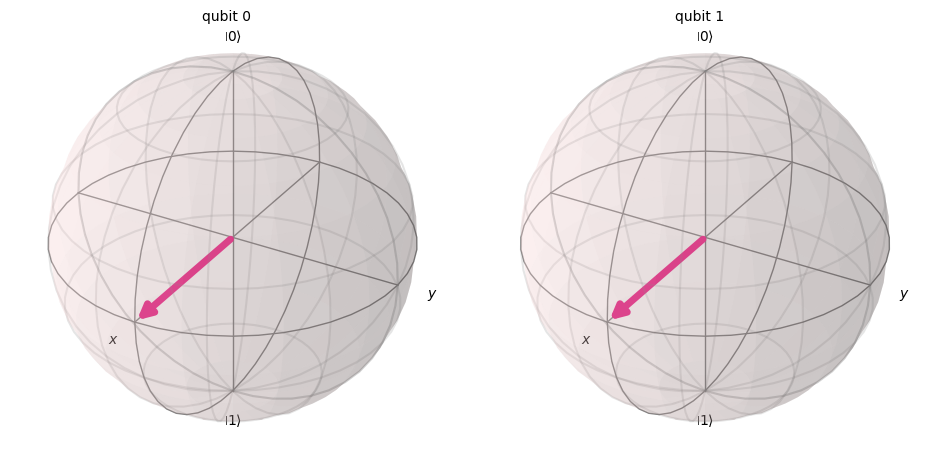

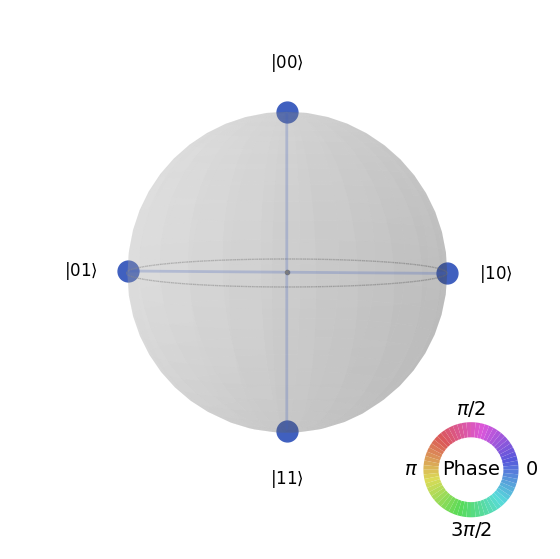

In [7]:
#a) - 1
qc_2 = QuantumCircuit(2)
qc_2.h(0)
qc_2.h(1)

state = Statevector.from_instruction(qc_2)
display(state.draw(output='latex'))


display(state.draw('bloch'))

display(state.draw('qsphere'))



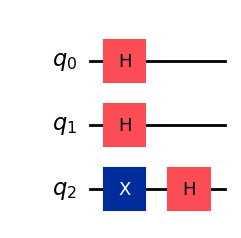

<IPython.core.display.Latex object>

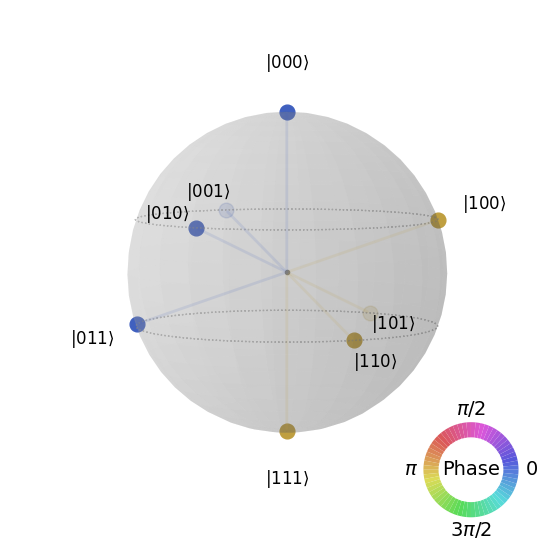

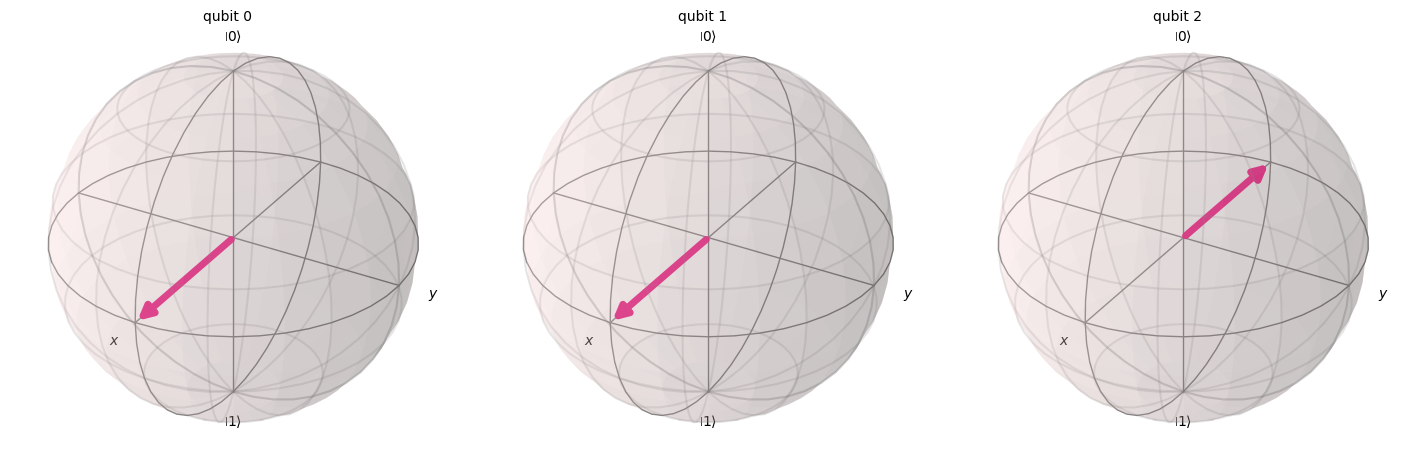

In [8]:
#a) - 2
qc = QuantumCircuit(3)

qc.x(2)

qc.h(0)
qc.h(1)
qc.h(2)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(state.draw("qsphere"))
display(state.draw("bloch"))

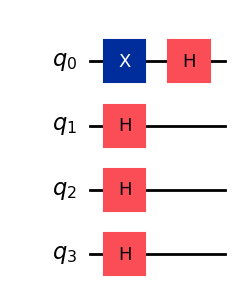

<IPython.core.display.Latex object>

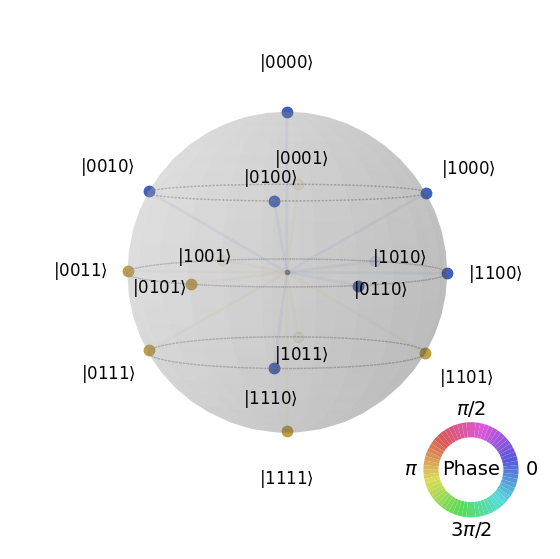

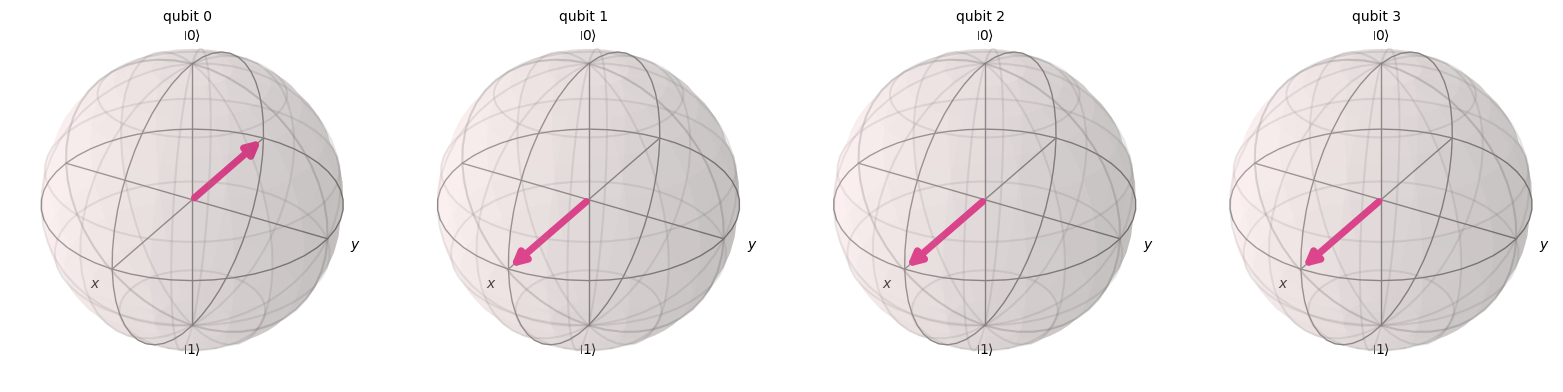

In [9]:
#a) - 3
qc = QuantumCircuit(4)

qc.x(0)

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

display(state.draw("latex"))
display(state.draw("qsphere"))
display(state.draw("bloch"))

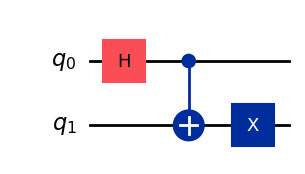

<IPython.core.display.Latex object>

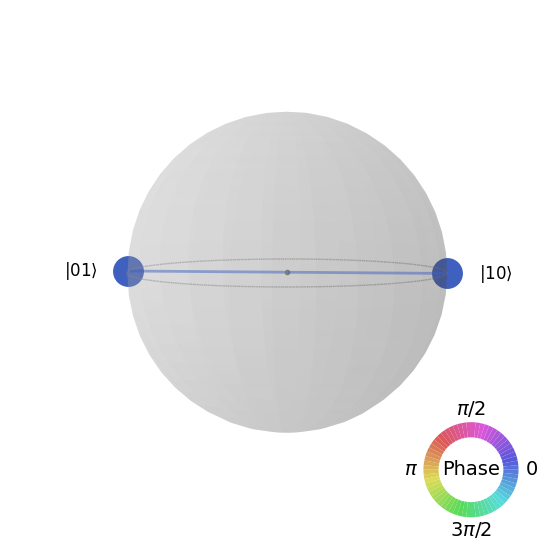

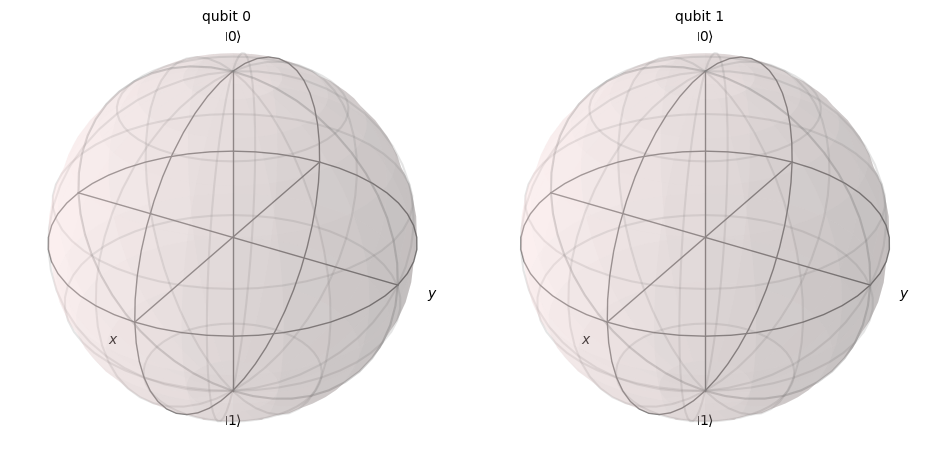

In [10]:
#Bell states
#b) - 1
qc_3 = QuantumCircuit(2)
# qc_3.x(0)

qc_3.h(0)
qc_3.cx(0, 1) #The first one is the control qubit, the second one is the target quibit
qc_3.x(1)

display(qc_3.draw('mpl'))
state = Statevector.from_instruction(qc_3)
display(state.draw(output='latex'))
display(state.draw("qsphere"))
display(state.draw("bloch"))

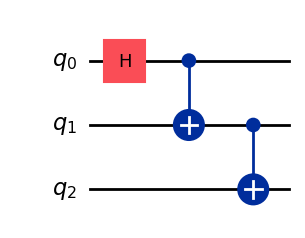

<IPython.core.display.Latex object>

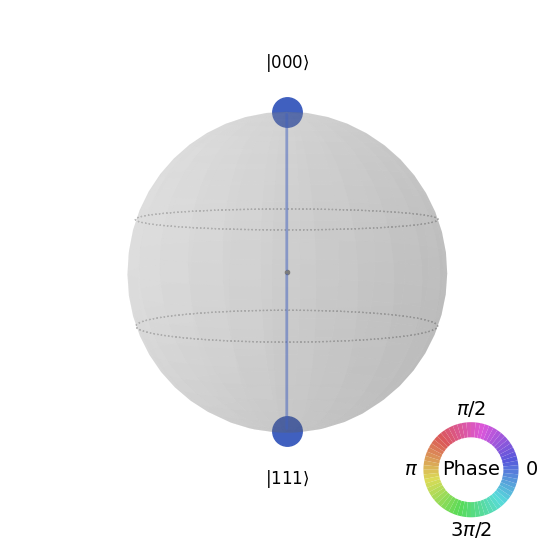

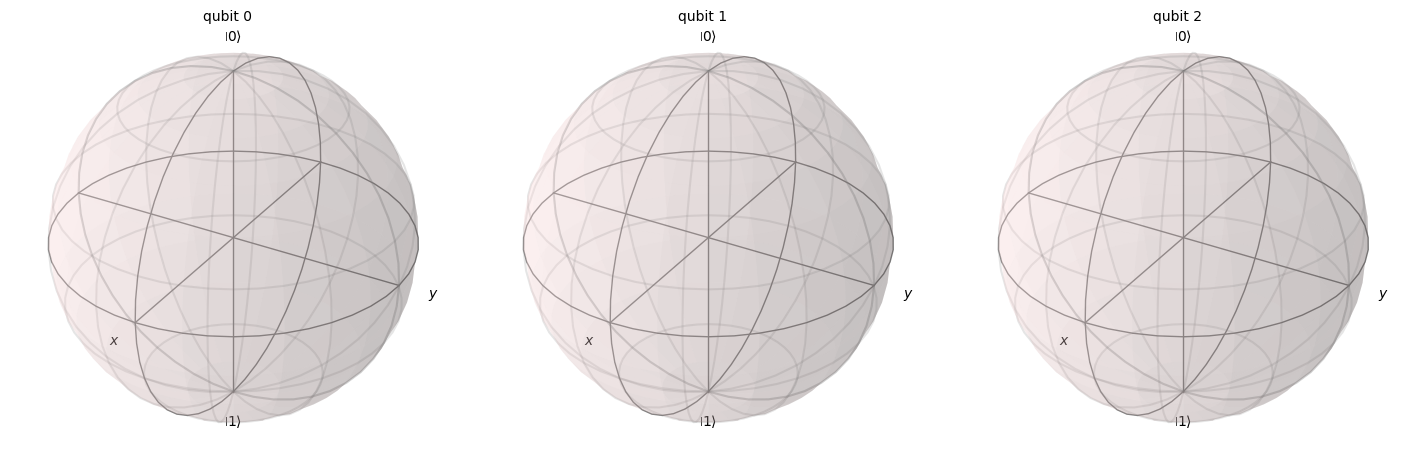

In [11]:
#Three qubit GHZ state
#b) - 2
qc_5= QuantumCircuit(3)
qc_5.h(0)
qc_5.cx(0, 1)
qc_5.cx(1, 2)

display(qc_5.draw('mpl'))
state = Statevector.from_instruction(qc_5)
display(state.draw(output='latex'))
display(state.draw("qsphere"))
display(state.draw("bloch"))

### 5. Matrix representation
Show matrix representation for CNOT. How the matrix representation changes when you reverse control and target qubits?

CNOT with control q0 and target q1


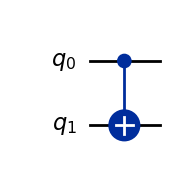

<IPython.core.display.Latex object>


CNOT with control q1 and target q0


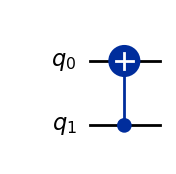

<IPython.core.display.Latex object>

In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from IPython.display import display
from qiskit.visualization import array_to_latex

print("CNOT with control q0 and target q1")

qc1 = QuantumCircuit(2)
qc1.cx(0,1)

display(qc1.draw("mpl"))

U1 = Operator(qc1).data

display(array_to_latex(U1))


print("\nCNOT with control q1 and target q0")

qc2 = QuantumCircuit(2)
qc2.cx(1,0)

display(qc2.draw("mpl"))

U2 = Operator(qc2).data

display(array_to_latex(U2))


# III. Jupyter Notebook, Qiskit, Quantum Circuits, Statevectors, Quantum simulators
https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector<br>
https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler
## Excercises
### 1. Write program in Jupyter Notebook responsible for creating circuits from excercise I.:
a) Veryfy that created circuits generate desired states by using ```Statevector``` class and function ```from_instruction()``` and function draw().<br>
Example - single qubit circuit:
```
qc_1 = QuantumCircuit(1)                   # creating 1 qubit quantum circuit
qc_1.h(0)                                  # adding hadamard gate
display(qc_1.draw('mpl'))                  # plotting circuit
state = Statevector.from_instruction(qc_1) # creating statevector ket resulting from applying the quantum ciruit qc_1 on 
                                           # the |0> initial state 
display(state.draw(output='latex'))        # displaying state in Dirac notation in latex output form
```
Example - two qubit circuit
```
qc = QuantumCircuit(2)
qc.h(0)
display(qc.draw('mpl'))
qc.cx(0, 1)
state = Statevector.from_instruction(qc)
display(state.draw(output='latex'))
```

b) Using function ```sample_counts()``` from ```Statevector``` class which generates "statistics" over given number of "shots", emulate outcome for a given number (shots) of mesurements, generate appriopriate histograms.<br>
Example:
```
outcome, v = state.measure()               # single measurement
print(f"Measured: {outcome}\nPost-measurement state:")
display(v.draw("latex"))
n_shots=1024 # specify numbert of shots.   # number of shots
statistics = state.sample_counts(n_shots)  # staticstics over n_shots measurements
display(statistics)                        
display(plot_histogram(statistics))        # plot histogram with number of measurements of avaliable states
display(plot_distribution(statistics))     # plot histogram with probabilites of avaliable states
```
c) Run the (noisless) quantum circuit and generate appriopriate histograms using ```StatevectorSampler``` class. <br>
Example for ```qc``` circuit:
```
#there has to be a measurement at the end of the qc circuit
qc.measure_all()
sampler = StatevectorSampler()
result = sampler.run([qc], shots=num_shots).result()
data_pub = result[0].data
counts = data_pub.meas.get_counts()
display(plot_histogram(counts), plot_distribution(counts))
```
d) Run the quantum circuit (including noise) using ```GenericBackendV2``` class for a backend (requires QiskitAer, pip install qiskit-aer)<br>
Example for ```qc``` circuit:
```
# Generate a nq-qubit simulated backend
nq=3
backend = GenericBackendV2(num_qubits=nq)

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc, backend)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated backend
job = backend.run(transpiled_circuit)
counts_r = job.result().get_counts()
display(plot_histogram(counts_r))
display(plot_distribution(counts_r))
```
e) Run the quantum circuit (including noise) using selected ```fake_provider``` (mimicking one of the existing quantum processors, e.g. FakeTorino) from fake provider module (https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider) for a backend. <br>
Example for ```qc``` circuit:
```
backend_FT=FakeTorino()
backend_FT.description

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc, backend_FT)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated backend
job = backend_FT.run(transpiled_circuit)
counts = job.result().get_counts()
plot_histogram(counts)
```

Example for ```qc``` circuit using ```SamplerV2``` primitive:

```
backend_FT=FakeTorino()
backend_FT.description

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc, backend_FT)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated fake backend
sampler = SamplerV2(backend_FT)
job = sampler.run([transpiled_circuit])
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()
plot_histogram(counts)
```


In below cells, there is a code for above exercises. Some exercises repeat itselves, so I focus only on one circuit.

In [13]:
#Three qubit states

qc_4 = QuantumCircuit(3)
qc_4.h(0)
qc_4.h(1)
qc_4.h(2)

state = Statevector.from_instruction(qc_4)
display(state.draw(output='latex'))

<IPython.core.display.Latex object>

Measured: 100
Post-measurement state:


<IPython.core.display.Latex object>

{np.str_('000'): np.int64(131),
 np.str_('001'): np.int64(135),
 np.str_('010'): np.int64(124),
 np.str_('011'): np.int64(139),
 np.str_('100'): np.int64(134),
 np.str_('101'): np.int64(137),
 np.str_('110'): np.int64(126),
 np.str_('111'): np.int64(98)}

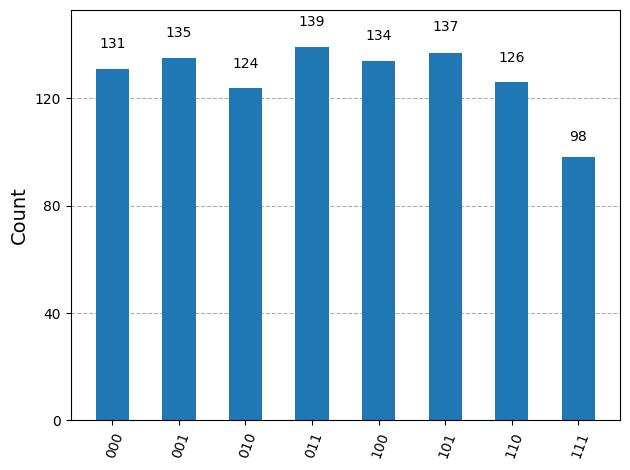

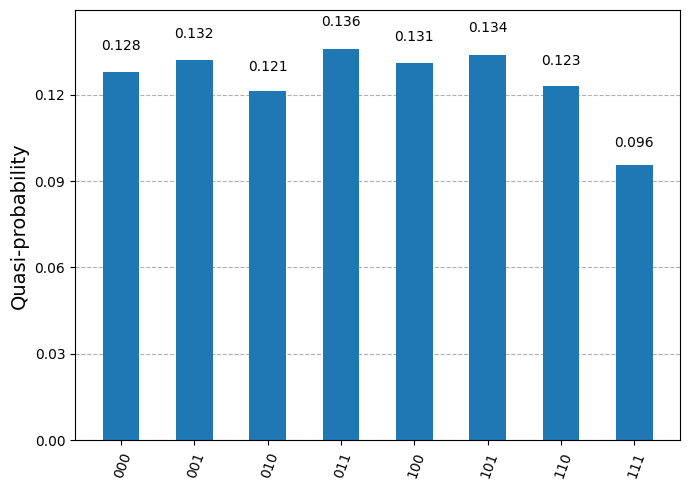

In [14]:
from qiskit.visualization import plot_histogram, plot_distribution

outcome, v = state.measure()               # single measurement
print(f"Measured: {outcome}\nPost-measurement state:")
display(v.draw("latex"))


n_shots=1024 # specify numbert of shots.   # number of shots
statistics = state.sample_counts(n_shots)  # staticstics over n_shots measurements
display(statistics)                        
display(plot_histogram(statistics))        # plot histogram with number of measurements of avaliable states
display(plot_distribution(statistics))     # plot histogram with probabilites of avaliable states

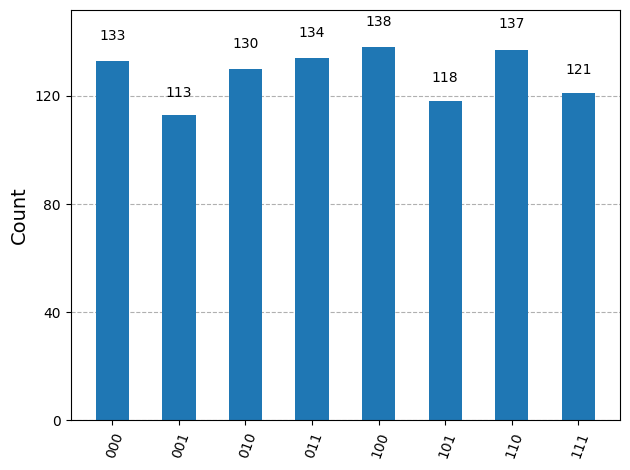

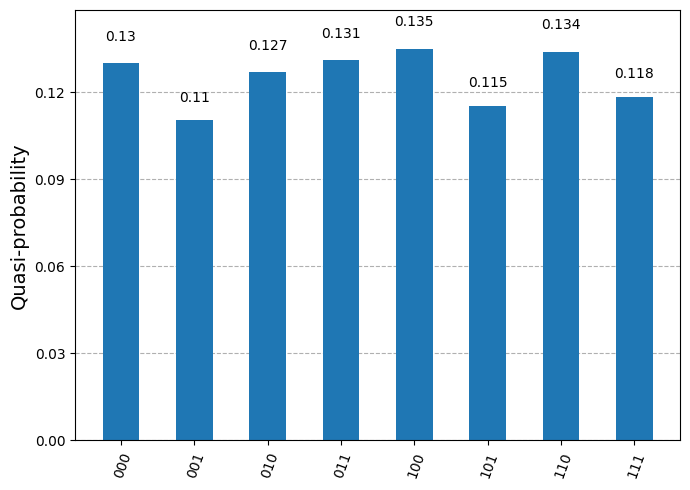

In [15]:
from qiskit.primitives import StatevectorSampler
# a little different approach to exercise
qc_4.measure_all()
sampler = StatevectorSampler()
result = sampler.run([qc_4], shots=1024).result()
data_pub = result[0].data
counts = data_pub.meas.get_counts()
display(plot_histogram(counts), plot_distribution(counts))

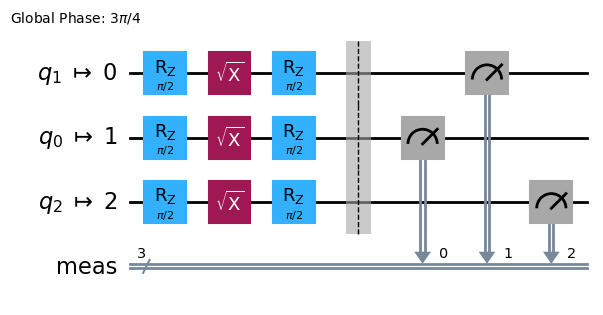

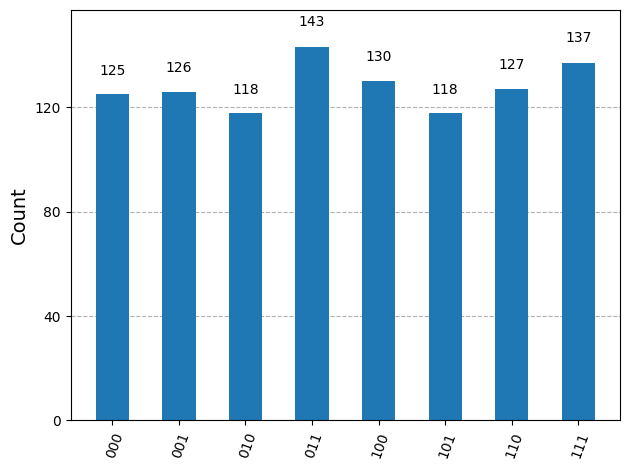

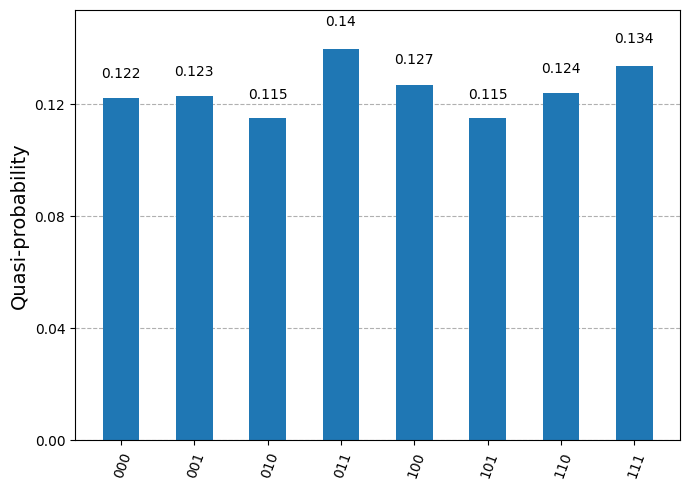

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram, plot_distribution
from IPython.display import display
nq=3
backend = GenericBackendV2(num_qubits=nq)

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc_4, backend)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated backend
job = backend.run(transpiled_circuit)
counts_r = job.result().get_counts()
display(plot_histogram(counts_r))
display(plot_distribution(counts_r))

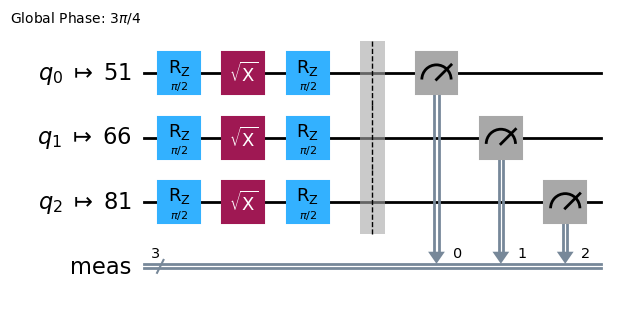

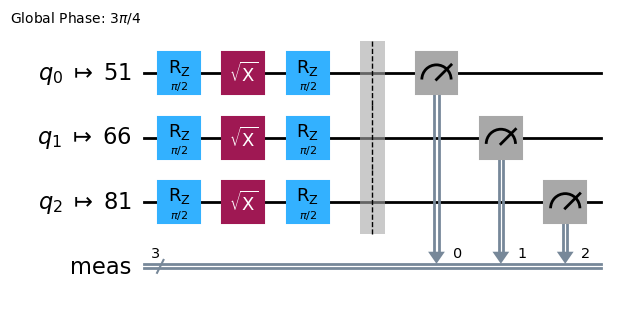

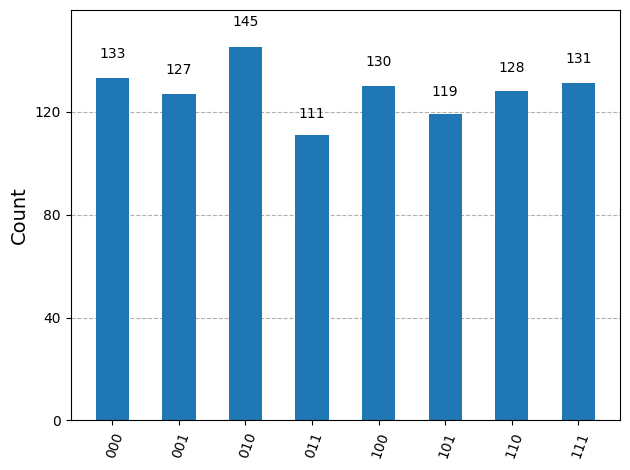

In [19]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeKyiv, FakeTorino
from qiskit_ibm_runtime import SamplerV2


backend_FT=FakeTorino()
backend_FT.description

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc_4, backend_FT)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated backend
job = backend_FT.run(transpiled_circuit)
counts = job.result().get_counts()
plot_histogram(counts)
# ```

# Example for ```qc``` circuit using ```SamplerV2``` primitive:

# ```
backend_FT=FakeTorino()
backend_FT.description

# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(qc_4, backend_FT)
display(transpiled_circuit.draw('mpl'))

# Run the transpiled circuit using the simulated fake backend
sampler = SamplerV2(backend_FT)
job = sampler.run([transpiled_circuit])
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()
plot_histogram(counts)


# HOMEWORK
## I. Jupyter Notebooks:
1. Finish exercises from laboratory classes and sent appropriate notebook via UPEL platform.
2. Create and run a quantum circuit resulting in superposition of 2 basis states being binary representation of ASCII code for the first letters of your name and surname. Prove that it generates proper superposition in similar manner as in exercise II.1. Compare the results between ideal noisless simulator and one of the fake backends mimicking real device. You can also try to run circuits on real backend however it requires IBMid (creating account on IBM quantum platform https://quantum.cloud.ibm.com/ - OPTIONALLY!).
3. In case of time consuming simulation check which bit in your two bit strings is fixed. Put it aside to add later. Limit your superposition bit strings to remaining 7 bits only. Then run the circuit again on a simulator and a real quantum device adding the 8th bit in post processing. Compare the results between perfect simulator and fake backend mimicking real device.
## II. Preparation for next classes, recommended reading 
1. Read a good article on quantum computing by John Preskill: https://arxiv.org/pdf/1801.00862.pdf
2. Install Qiskit and Jupyter Notebook on you computer at home. Best approach is to install Anaconda and then Qiskit (google for qiskit installation).
3. (OPTIONALLY!) Try to create a IBMid to have an access to IBM quantum platform https://quantum.cloud.ibm.com/
4. Read about ***Deutsch algorithm*** and ***Deutsch-Jozsa algorithm***, then try to understand how they work. These are the simple algorithms demonstrating quantum computer benefits. You can find a lot of resources online, including videos on this. So, please explore.

# Imports
```
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeKyiv, FakeTorino
from qiskit_ibm_runtime import SamplerV2
```

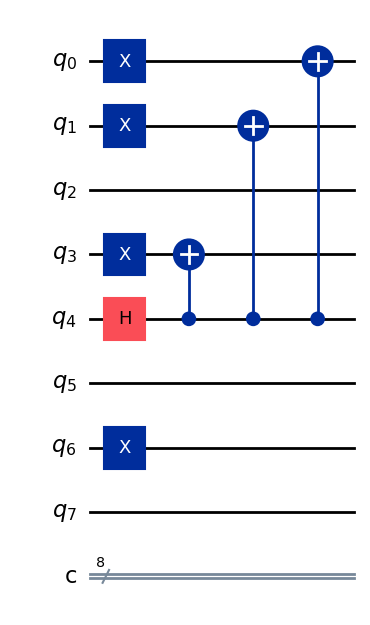

<IPython.core.display.Latex object>

{'01010000': 2049, '01001011': 2047}


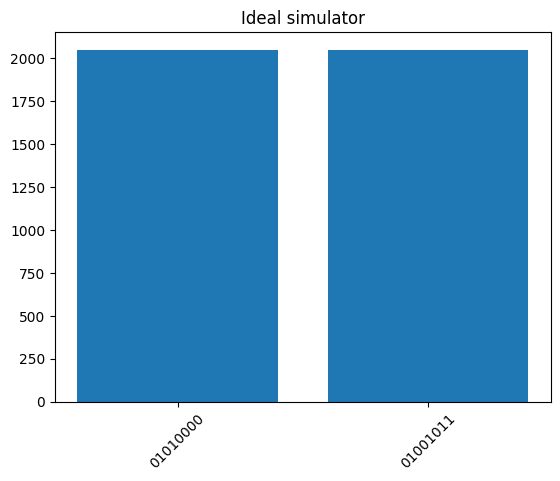

In [ ]:
# ASCII NAME - HOMEWORK

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# K = 0 1 0 0 1 0 1 1
# P = 0 1 0 1 0 0 0 0

qc = QuantumCircuit(8, 8)

qc.x(6)
qc.x(3)
qc.x(1)
qc.x(0)

qc.h(4)

qc.cx(4, 3)
qc.cx(4, 1)
qc.cx(4, 0)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
display(state.draw(output="latex"))

qc_meas = qc.copy()
qc_meas.measure(range(8), range(8))

backend = AerSimulator()
compiled = transpile(qc_meas, backend)
result = backend.run(compiled, shots=4096).result()
counts = result.get_counts()

print(counts)

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title("Ideal simulator")
plt.show()

Fake backend counts:
{'01001011': 1940, '01101010': 1, '01011000': 22, '01000011': 46, '11001011': 17, '01010000': 1873, '11010000': 15, '01011011': 23, '01001010': 16, '01001110': 1, '01110000': 13, '01000000': 21, '01000001': 10, '00001011': 17, '01001001': 11, '01010010': 17, '01101011': 16, '01010001': 10, '00010000': 11, '01010100': 6, '01001111': 6, '11000010': 1, '00010010': 1, '01000111': 1, '01100011': 1}


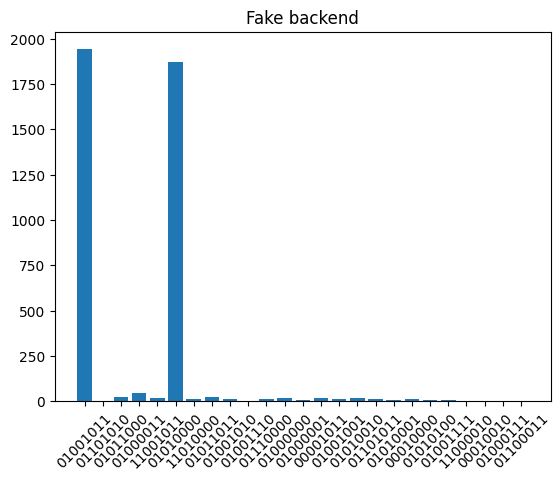

In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeAuckland

fake_backend = FakeAuckland()
noisy_backend = AerSimulator.from_backend(fake_backend)

compiled_noisy = transpile(qc_meas, noisy_backend)
result_noisy = noisy_backend.run(compiled_noisy, shots=4096).result()
counts_noisy = result_noisy.get_counts()

print("Fake backend counts:")
print(counts_noisy)

plt.figure()
plt.bar(counts_noisy.keys(), counts_noisy.values())
plt.xticks(rotation=45)
plt.title("Fake backend")
plt.show()